### Libraries

In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import accuracy_score, auc, roc_curve
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten

### Setup

In [10]:
# Read the data from CSV files
DATA_PATH = 'data/'

train_df = pd.read_csv(f'{DATA_PATH}train_churn_dataset.csv')
val_df = pd.read_csv(f'{DATA_PATH}val_churn_dataset.csv')
test_df = pd.read_csv(f'{DATA_PATH}test_churn_dataset.csv')

In [11]:
# Prepare data
X_train = train_df.drop(columns=['Churn'])
y_train = train_df['Churn']
X_val = val_df.drop(columns=['Churn'])
y_val = val_df['Churn']
X_test = test_df.drop(columns=['Churn'])
y_test = test_df['Churn']

In [12]:
print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("Test set size:", len(X_test))

# Distribution of labels in the training set
train_labels = y_train.values

print("\nTraining set label distribution:")
print(pd.Series(train_labels).value_counts(normalize=True))

Training set size: 314599
Validation set size: 67414
Test set size: 67415

Training set label distribution:
1    0.500002
0    0.499998
Name: proportion, dtype: float64


In [13]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Model Training

In [14]:
# Reshape data for Conv1D (add sequence dimension)
X_train_reshaped = X_train.values.reshape((X_train.shape[0], X_train.shape[1], 1)) if isinstance(X_train, pd.DataFrame) else X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_reshaped = X_val.values.reshape((X_val.shape[0], X_val.shape[1], 1)) if isinstance(X_val, pd.DataFrame) else X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

In [35]:
# Build CNN model for tabular data
model = Sequential([
    Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(1, activation='sigmoid')
])

In [36]:
# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

model.summary()

# Train with reshaped data
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_train_reshaped, y_train,
    validation_data=(X_val_reshaped, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - AUC: 0.9436 - accuracy: 0.9109 - loss: 0.2559 - val_AUC: 0.9483 - val_accuracy: 0.9216 - val_loss: 0.2234
Epoch 2/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - AUC: 0.9489 - accuracy: 0.9224 - loss: 0.2235 - val_AUC: 0.9498 - val_accuracy: 0.9225 - val_loss: 0.2181
Epoch 3/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - AUC: 0.9499 - accuracy: 0.9232 - loss: 0.2191 - val_AUC: 0.9505 - val_accuracy: 0.9229 - val_loss: 0.2139
Epoch 4/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - AUC: 0.9506 - accuracy: 0.9236 - loss: 0.2168 - val_AUC: 0.9513 - val_accuracy: 0.9233 - val_loss: 0.2118
Epoch 5/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - AUC: 0.9513 - accuracy: 0.9241 - loss: 0.2142 - val_AUC: 0.9511 - val_accuracy: 0.9238 - val_loss: 0.2098
Epoch 6/30
9832/9832 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - AUC: 0.9516 - accuracy: 0.9244 - loss: 0.2127 - val_AUC: 0.9512 - val_accuracy: 0.9241 - val_loss: 0.2077
Epoch 7/30
9832/9832 ━

### Model Evaluation

In [38]:
# Reshape test data for Conv1D
X_test_reshaped = X_test.values.reshape((X_test.shape[0], X_test.shape[1], 1))

In [39]:
# Test the model on the test set
y_pred_prob = model.predict(X_test_reshaped)  # Get predicted probabilities
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary predictions

2107/2107 ━━━━━━━━━━━━━━━━━━━━ 1s 386us/step


In [40]:
# Classification report
report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

accuracy = accuracy_score(y_test, y_pred)
precision = report["1"]["precision"]
recall = report["1"]["recall"]
f1 = report["1"]["f1-score"]

print(f"CLASSIFICATION REPORT:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

CLASSIFICATION REPORT:
Accuracy: 0.9259808647927019
Precision: 0.8746510110893673
Recall: 0.9944818583676981
F1-score: 0.9307252332296757


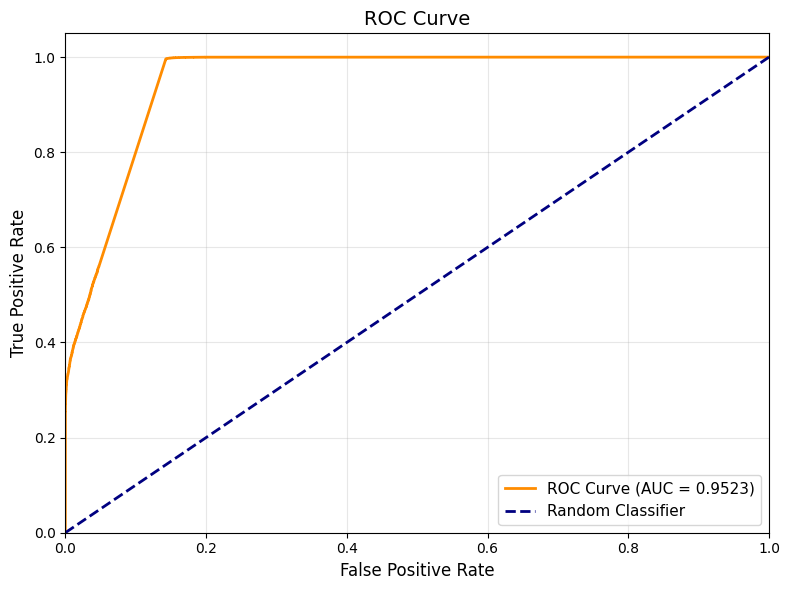

AUC Score: 0.9523


In [43]:
# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('roc_auc_curve.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

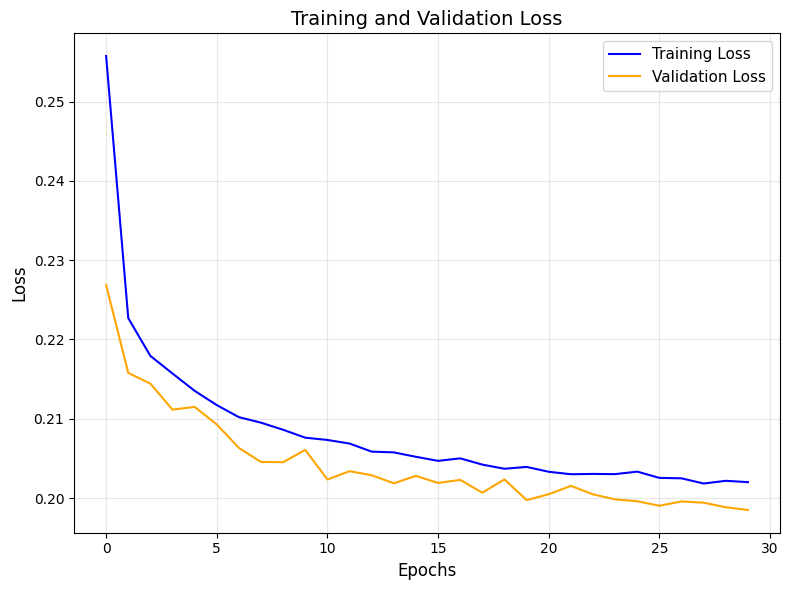

In [23]:
# Training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()


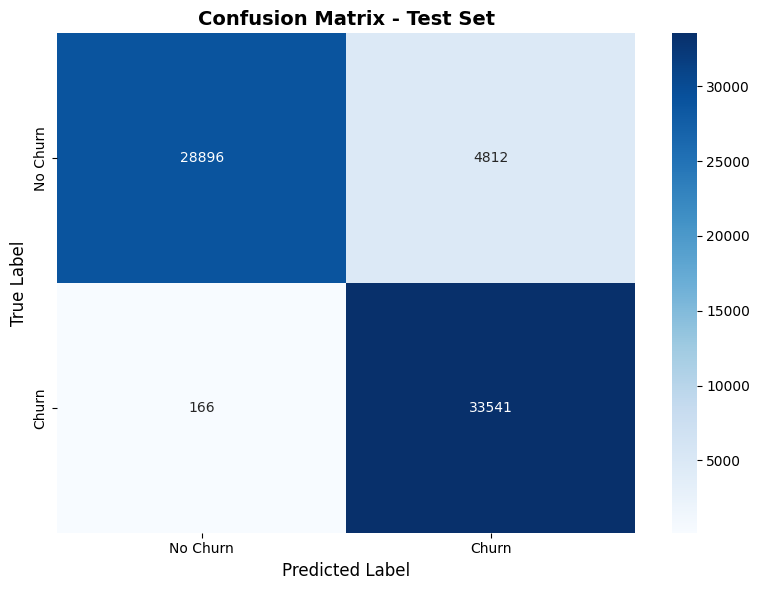

In [24]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
 
# Create the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # Show numbers in cells
    fmt='d',     # Format as integers
    cmap='Blues',  # Color palette
    cbar=True,   # Show color bar
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
 
plt.title('Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()